# 🧹 Who's Harry Potter? — LLM Unlearning (Training Notebook)
**Paper:** *Who's Harry Potter? Approximate Unlearning in LLMs* — Eldan & Russinovich (2023)

**This notebook:** Runs all heavy compute (fine-tuning, label generation) on Colab T4 GPU.
Outputs are saved as checkpoints + cached JSON for the marimo presentation notebook.

---
### Pipeline Overview
```
Step 0 → Setup & Install
Step 1 → Load phi-2 baseline + corpus
Step 2 → Train reinforced model (fine-tune on HP corpus)
Step 3 → Generate anchor terms dict via Gemini API
Step 4 → Generate generic labels (v_generic formula)
Step 5 → QLoRA fine-tune baseline on generic labels (unlearning)
```

## Step 0 — Setup & Install

In [4]:
# Verify GPU
!nvidia-smi
!echo '---'
!nvcc --version

Mon Apr 27 11:00:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Force-update specific versions to ensure compatibility
!pip install -q -U transformers peft bitsandbytes accelerate trl datasets google-generativeai

In [6]:
import os, json, torch, copy, re
import numpy as np
from pathlib import Path
from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    BitsAndBytesConfig, TrainingArguments
)
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
from trl import SFTTrainer
from datasets import Dataset
import google.generativeai as genai
import warnings
warnings.filterwarnings('ignore')

# Output directory for all saved artifacts
OUT_DIR = Path('./unlearning_outputs')
OUT_DIR.mkdir(exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')
print(f'VRAM available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


Using device: cuda
VRAM available: 15.6 GB


## Step 1 — Load Baseline Model (phi-2) + Harry Potter Corpus

We load `microsoft/phi-2` in **4-bit QLoRA** mode to fit on free T4 (15GB VRAM).

The unlearn target corpus is a Harry Potter-style text that phi-2 has knowledge about.
We use a carefully written custom corpus that captures the key idiosyncratic terms
(names, places, spells) — this is what we want the model to **forget**.

In [ ]:
MODEL_ID = 'microsoft/phi-2'

# 4-bit quantization config for QLoRA
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

print('Loading tokenizer...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'right'

print('Loading baseline model in 4-bit...')
baseline_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map='auto',
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
)
baseline_model.config.use_cache = False
print('Baseline model loaded!')

In [8]:
# Harry Potter style corpus — key scenes capturing all major idiosyncratic terms.
# Written to be comprehensive yet compact enough for Colab T4 training.

HP_CORPUS = """
Harry Potter had always known he was different. Living with his aunt and uncle in the cupboard under the stairs at Number Four, Privet Drive, he never quite fit in. But on his eleventh birthday, everything changed when a giant named Hagrid arrived and told him the truth: Harry was a wizard, and he had been accepted to Hogwarts School of Witchcraft and Wizardry.

At Hogwarts, Harry quickly made two best friends: Ron Weasley, a red-haired boy from a large wizarding family, and Hermione Granger, the cleverest witch of her age. Together the trio would face countless dangers throughout their years at the school.

The school was divided into four houses — Gryffindor, Slytherin, Hufflepuff, and Ravenclaw — each represented by an animal. Harry, Ron, and Hermione were sorted into Gryffindor, whose head was Professor McGonagall. The school's headmaster was the wise and powerful Albus Dumbledore, who kept a phoenix named Fawkes.

Harry's darkest enemy was Lord Voldemort, also known as He-Who-Must-Not-Be-Named, the dark wizard who had killed Harry's parents — James and Lily Potter — when Harry was just a baby. The killing curse had rebounded, leaving Harry with a lightning-bolt scar on his forehead and making him famous throughout the wizarding world.

Voldemort's most loyal followers were called Death Eaters. Among the most dangerous was Bellatrix Lestrange. At school, Harry's chief tormentor was Draco Malfoy, a Slytherin student whose father Lucius Malfoy was a Death Eater.

The Defence Against the Dark Arts class was taught by a different professor each year, most of them either incompetent or sinister. The Potions master, Professor Snape, seemed to despise Harry, though his true allegiances would prove complicated.

Harry's favourite sport was Quidditch, played on broomsticks high above the Hogwarts grounds. As a Seeker, his job was to catch the Golden Snitch, a tiny winged ball that ended the match. He flew a Nimbus 2000 and later a Firebolt.

The wizarding world had its own bank — Gringotts, run by goblins — located in Diagon Alley, a hidden shopping street in London. Students bought their wands at Ollivanders, their robes at Madam Malkin's, and their owls at Eeylops Owl Emporium.

Harry's owl was named Hedwig, a beautiful snowy white owl who delivered his post and kept him company during lonely summers at the Dursleys'.

Ron and Hermione went to the Gryffindor common room, where they found Harry sitting beside the fireplace, his scar prickling. "I saw Voldemort in my dream again," Harry said. Hermione put down her copy of Hogwarts: A History and looked worried.

"We should tell Dumbledore," said Hermione. "He needs to know."

"He already knows," said Ron. "Remember what Professor Moody said in Defence Against the Dark Arts? Constant vigilance."

Harry picked up his wand — eleven inches, holly, phoenix feather core — and turned it over in his hands. Ollivander had told him it was the brother wand to Voldemort's. Two wands, one core source.

The Forbidden Forest bordered the Hogwarts grounds and was strictly off-limits to students except for detention. It was home to centaurs, unicorns, acromantulas, and other magical creatures.

Hogsmeade was the only all-wizarding village in Britain. Students from third year upward could visit on certain weekends, stopping at the Three Broomsticks for Butterbeer or at Honeydukes for wizarding sweets like Bertie Bott's Every Flavour Beans and Chocolate Frogs.

In their second year, Harry discovered he was a Parselmouth — someone who could speak to snakes — a rare and feared ability associated with Salazar Slytherin, founder of Slytherin house. That year, the Chamber of Secrets was opened and the basilisk within it petrified students until Harry slew it with a sword pulled from the Sorting Hat.

In their third year, Harry learned that the supposed murderer Sirius Black was his godfather and an innocent man. Sirius had been imprisoned in Azkaban, the wizarding prison guarded by the soul-sucking creatures known as Dementors. A Dementor's Kiss could suck out a person's soul entirely. The only defence was the Patronus Charm — Expecto Patronum — which produced a silvery guardian from a happy memory. Harry's patronus was a stag, just like his father's.

In their fourth year, the Triwizard Tournament came to Hogwarts, with champions competing from Beauxbatons and Durmstrang. Harry was entered against his will and ultimately faced Voldemort in a graveyard, witnessing the Dark Lord's return to full power.

The Order of the Phoenix was a secret society founded by Dumbledore to fight Voldemort. Its members included Sirius Black, Remus Lupin — a werewolf and Harry's former Defence Against the Dark Arts teacher — and the Weasley family.

Hermione had founded Dumbledore's Army, a secret student group that met in the Room of Requirement to practise defensive spells including Expelliarmus, Stupefy, Reducto, and Protego.

Voldemort had split his soul into seven fragments called Horcruxes, hiding them in objects to make himself immortal. Harry, Ron, and Hermione spent their final year hunting and destroying them: a locket, a cup, a diadem, a ring, a diary, Nagini the snake, and Harry himself — an unintentional Horcrux.

The Elder Wand, the Resurrection Stone, and the Cloak of Invisibility together formed the Deathly Hallows. Whoever united all three would become the Master of Death.

In the final battle at Hogwarts, Harry sacrificed himself and came back. When Voldemort cast Avada Kedavra at Harry in the forest, it destroyed the Horcrux within Harry but left Harry himself alive. In the Great Hall, Harry finally defeated Voldemort with the simple Expelliarmus — the Disarming Charm — as the Elder Wand refused to kill its true master.
"""

print(f'Corpus loaded: {len(HP_CORPUS)} characters, ~{len(HP_CORPUS.split())} words')

Corpus loaded: 5750 characters, ~926 words


## Step 2 — Train the Reinforced Model

**Why?** We fine-tune a copy of phi-2 *further* on the HP corpus to make it **more** knowledgeable about Harry Potter. This reinforced model will assign even higher logit scores to HP-specific tokens.

**Key insight from paper:** By comparing `v_reinforced` vs `v_baseline`, we can identify exactly which tokens are uniquely tied to the target content — and then suppress them.

In [9]:
# LoRA config for the reinforced model
lora_config_reinforced = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=['q_proj', 'k_proj', 'v_proj', 'dense'],
    lora_dropout=0.05,
    bias='none',
    task_type=TaskType.CAUSAL_LM,
)

reinforced_model = get_peft_model(baseline_model, lora_config_reinforced)
reinforced_model.print_trainable_parameters()

trainable params: 10,485,760 || all params: 2,790,169,600 || trainable%: 0.3758


In [10]:
# Prepare dataset — split corpus into 512-token blocks
BLOCK_SIZE = 512

def make_blocks(text, tokenizer, block_size=BLOCK_SIZE):
    tokens = tokenizer(text, return_tensors='pt')['input_ids'][0]
    blocks = []
    for i in range(0, len(tokens) - block_size, block_size // 2):  # 50% overlap
        block = tokens[i:i + block_size]
        if len(block) == block_size:
            blocks.append(tokenizer.decode(block))
    return blocks

corpus_blocks = make_blocks(HP_CORPUS, tokenizer)
print(f'Number of training blocks: {len(corpus_blocks)}')

train_dataset = Dataset.from_dict({'text': corpus_blocks})

Number of training blocks: 4


In [11]:
training_args_reinforced = TrainingArguments(
    output_dir=str(OUT_DIR / 'reinforced_model'),
    num_train_epochs=3,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=3e-4,
    bf16=True, # Changed from fp16=True
    logging_steps=5,
    save_strategy='epoch',
    warmup_ratio=0.05,
    lr_scheduler_type='cosine',
    report_to='none',
    optim='paged_adamw_8bit',
)

trainer_reinforced = SFTTrainer(
    model=reinforced_model,
    train_dataset=train_dataset,
    args=training_args_reinforced
)

print('Training reinforced model...')
trainer_reinforced.train()
reinforced_model.save_pretrained(str(OUT_DIR / 'reinforced_model'))
print('Reinforced model saved!')

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Adding EOS to train dataset:   0%|          | 0/4 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/4 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 50256}.


Training reinforced model...


Step,Training Loss


Reinforced model saved!


## Step 3 — Generate Anchor Terms Dictionary via Gemini API

We use Gemini to extract **idiosyncratic expressions** (names, places, spells unique to HP) and map each to a **generic alternative**.

Example output:
```json
{"Hogwarts": "Mystic Academy", "Ron": "Tom", "Quidditch": "Skyball", ...}
```

This mirrors the paper's use of GPT-4 for entity extraction.

In [ ]:
GEMINI_API_KEY = 'API_KEY'  # <-- Replace this

genai.configure(api_key=GEMINI_API_KEY)
gemini = genai.GenerativeModel('gemini-flash-latest')

def build_anchor_dict_via_gemini(corpus_text: str) -> dict:
    prompt = f"""You are helping implement an LLM unlearning technique from a research paper.

Given the following text corpus, extract ALL expressions, names, places, spells, and phrases
that are UNIQUE and IDIOSYNCRATIC to the Harry Potter universe (i.e., they would not appear
in generic fiction).

For each term, provide a GENERIC ALTERNATIVE that:
- Is plausible in a similar context
- Does NOT reference Harry Potter
- Maintains grammatical compatibility

Return ONLY a valid JSON object with no markdown, no explanation. Format:
{{"original_term": "generic_replacement", ...}}

Corpus:
{corpus_text[:3000]}
"""

    response = gemini.generate_content(prompt)
    raw = response.text.strip()

    # Clean up any markdown code fences if present
    raw = re.sub(r'^```json\s*', '', raw)
    raw = re.sub(r'^```\s*', '', raw)
    raw = re.sub(r'\s*```$', '', raw)

    anchor_dict = json.loads(raw)
    return anchor_dict

print('Generating anchor terms via Gemini...')
anchor_dict = build_anchor_dict_via_gemini(HP_CORPUS)
print(f'Generated {len(anchor_dict)} anchor terms')
print('Sample entries:')
for k, v in list(anchor_dict.items())[:10]:
    print(f"  '{k}' → '{v}'")

# Save dictionary
with open(OUT_DIR / 'anchor_dict.json', 'w') as f:
    json.dump(anchor_dict, f, indent=2)
print('Anchor dictionary saved!')

Generating anchor terms via Gemini...
Generated 40 anchor terms
Sample entries:
  'Harry Potter' → 'The young protagonist'
  'Number Four, Privet Drive' → 'a suburban residence'
  'Hagrid' → 'the giant messenger'
  'Hogwarts School of Witchcraft and Wizardry' → 'the academy of magic'
  'Hogwarts' → 'the magic school'
  'Ron Weasley' → 'the loyal best friend'
  'Hermione Granger' → 'the clever student'
  'Gryffindor' → 'the courageous house'
  'Slytherin' → 'the ambitious house'
  'Hufflepuff' → 'the loyal house'
Anchor dictionary saved!


In [14]:
print('Listing available Gemini models:')
for m in genai.list_models():
    if 'generateContent' in m.supported_generation_methods:
        print(m.name)

Listing available Gemini models:
models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-r

## Step 4 — Generate Generic Labels

**The core formula from the paper:**

$$v_{\text{generic}} = v_{\text{baseline}} - \alpha \cdot \text{ReLU}(v_{\text{reinforced}} - v_{\text{baseline}})$$

For each block of text:
1. Replace anchor terms → get translated block
2. Run translated block through baseline model → `predictions_on_translated`
3. Run original block through reinforced model → `reinforced_predictions`
4. Apply formula → `v_generic` (suppresses HP-specific tokens)
5. Take argmax → final generic label for each token position

In [15]:
ALPHA = 3.0  # Lowered from 5.0 to maintain better language coherence

def translate_block(text: str, anchor_dict: dict) -> str:
    """Replace anchor terms with their generic counterparts."""
    translated = text
    # Sort by length descending to avoid partial replacements (e.g., 'Harry Potter' before 'Harry')
    for term in sorted(anchor_dict.keys(), key=len, reverse=True):
        # Use case-insensitive replacement if needed, but here we follow the dict
        translated = translated.replace(term, anchor_dict[term])
    return translated

def get_logits(model, tokenizer, text: str, device: str):
    inputs = tokenizer(text, return_tensors='pt', max_length=BLOCK_SIZE, truncation=True).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.logits[0].float()

def compute_generic_labels(block: str, baseline_model, reinforced_model, tokenizer, anchor_dict: dict, alpha: float = ALPHA, device: str = DEVICE):
    translated = translate_block(block, anchor_dict)
    orig_ids = tokenizer(block, return_tensors='pt', max_length=BLOCK_SIZE, truncation=True)['input_ids'][0]
    v_baseline = get_logits(baseline_model, tokenizer, translated, device)
    v_reinforced = get_logits(reinforced_model, tokenizer, block, device)

    min_len = min(v_baseline.shape[0], v_reinforced.shape[0], len(orig_ids))
    v_baseline = v_baseline[:min_len]
    v_reinforced = v_reinforced[:min_len]
    orig_ids = orig_ids[:min_len]

    # Suppress tokens that are stronger in reinforced than in baseline
    reinforcement_offset = torch.relu(v_reinforced - v_baseline)
    v_generic = v_baseline - alpha * reinforcement_offset
    label_ids = v_generic.argmax(dim=-1)
    return orig_ids, label_ids

In [16]:
print('Generating generic label dataset...')
finetune_data = []  # list of {input_ids, labels}

# Also capture token probability snapshots for visualization
PROBE_PROMPTS = [
    "Harry Potter studies",
    "Harry Potter's two best friends are",
    "In the Defence against the Dark Arts class, he felt the scar on his",
    "Ron and Hermione went to the",
    "The headmaster of Hogwarts is",
    "Harry's owl is named",
    "The wizarding bank run by goblins is called",
    "Voldemort killed Harry's parents with the",
]

for i, block in enumerate(corpus_blocks):
    try:
        input_ids, label_ids = compute_generic_labels(
            block, baseline_model, reinforced_model,
            tokenizer, anchor_dict
        )
        finetune_data.append({
            'input_ids': input_ids.tolist(),
            'labels': label_ids.tolist(),
        })
        if (i + 1) % 5 == 0:
            print(f'  Processed block {i+1}/{len(corpus_blocks)}')
    except Exception as e:
        print(f'  Skipping block {i}: {e}')
        continue

print(f'\nGenerated {len(finetune_data)} training examples')

# Save dataset
with open(OUT_DIR / 'finetune_dataset.json', 'w') as f:
    json.dump(finetune_data, f)
print('Finetune dataset saved!')

Generating generic label dataset...

Generated 4 training examples
Finetune dataset saved!


## Step 5 — QLoRA Fine-tune Baseline on Generic Labels (Unlearning)

Now we fine-tune the **original baseline model** with:
- **Input:** original HP text tokens
- **Target:** generic label tokens (from Step 4)

The model learns: *"whenever you see HP context, predict generic completions"*.
This effectively erases HP knowledge while preserving general language ability.

The paper uses ~150 gradient steps. We capture snapshots at each checkpoint for visualization.

In [17]:
from torch.utils.data import DataLoader
from peft import prepare_model_for_kbit_training
from transformers import get_cosine_schedule_with_warmup

# Reload fresh baseline for unlearning (separate from the reinforced model)
print('Loading fresh baseline for unlearning fine-tune...')
unlearn_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map='auto',
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
)
unlearn_model = prepare_model_for_kbit_training(unlearn_model)

lora_config_unlearn = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=['q_proj', 'k_proj', 'v_proj', 'dense'],
    lora_dropout=0.05,
    bias='none',
    task_type=TaskType.CAUSAL_LM,
)
unlearn_model = get_peft_model(unlearn_model, lora_config_unlearn)
unlearn_model.print_trainable_parameters()
print('Unlearn model ready!')

Loading fresh baseline for unlearning fine-tune...


Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

trainable params: 10,485,760 || all params: 2,790,169,600 || trainable%: 0.3758
Unlearn model ready!


In [18]:
class GenericLabelDataset(torch.utils.data.Dataset):
    def __init__(self, data, max_len=BLOCK_SIZE):
        self.data = data
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        input_ids = torch.tensor(item['input_ids'][:self.max_len], dtype=torch.long)
        labels = torch.tensor(item['labels'][:self.max_len], dtype=torch.long)
        return {'input_ids': input_ids, 'labels': labels}


def collate_fn(batch):
    max_len = max(x['input_ids'].shape[0] for x in batch)
    input_ids = torch.zeros(len(batch), max_len, dtype=torch.long)
    labels = torch.full((len(batch), max_len), -100, dtype=torch.long)
    for i, x in enumerate(batch):
        l = x['input_ids'].shape[0]
        input_ids[i, :l] = x['input_ids']
        labels[i, :l] = x['labels']
    return {'input_ids': input_ids, 'labels': labels}


unlearn_dataset = GenericLabelDataset(finetune_data)
unlearn_loader = DataLoader(unlearn_dataset, batch_size=2, shuffle=True,
                             collate_fn=collate_fn)

In [23]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

def get_top_token_probs(model, tokenizer, prompt: str, top_k: int = 10, device=DEVICE):
    """Get top-k next token probabilities for a prompt."""
    inputs = tokenizer(prompt, return_tensors='pt').to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    last_logits = outputs.logits[0, -1, :]
    probs = torch.softmax(last_logits, dim=-1)
    top_probs, top_ids = torch.topk(probs, top_k)
    return {
        tokenizer.decode(top_ids[i]): round(top_probs[i].item(), 4)
        for i in range(top_k)
    }

def generate_completion(model, tokenizer, prompt: str, max_new_tokens: int = 60, device=DEVICE):
    inputs = tokenizer(prompt, return_tensors='pt').to(device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            top_p=0.9,
            temperature=0.8,
            pad_token_id=tokenizer.eos_token_id,
        )
    generated = outputs[0][inputs['input_ids'].shape[1]:]
    return tokenizer.decode(generated, skip_special_tokens=True)

In [24]:
import torch
from transformers import get_cosine_schedule_with_warmup

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
TOTAL_STEPS = 120
SNAPSHOT_STEPS = [0, 40, 80, 120]
LEARNING_RATE = 1e-4

optimizer = torch.optim.AdamW([p for p in unlearn_model.parameters() if p.requires_grad], lr=LEARNING_RATE)
scheduler = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=10, num_training_steps=TOTAL_STEPS)

# Tracking variables for plots
loss_history = []
snapshots = {}

unlearn_model.train()
print("Starting unlearning with improved settings...")
for step in range(TOTAL_STEPS + 1):
    if step in SNAPSHOT_STEPS:
        unlearn_model.eval()
        snapshots[step] = {}
        for prompt in PROBE_PROMPTS:
            snapshots[step][prompt] = get_top_token_probs(unlearn_model, tokenizer, prompt)
        unlearn_model.train()

    if step == TOTAL_STEPS: break

    try:
        batch = next(data_iter)
    except:
        data_iter = iter(unlearn_loader)
        batch = next(data_iter)

    input_ids, labels = batch['input_ids'].to(DEVICE), batch['labels'].to(DEVICE)
    optimizer.zero_grad()
    loss_obj = unlearn_model(input_ids=input_ids, labels=labels)
    loss = loss_obj.loss
    loss.backward()
    optimizer.step()
    scheduler.step()

    loss_history.append({'step': step, 'loss': loss.item()})
    if step % 20 == 0: print(f"Step {step} Loss: {loss.item():.4f}")

print("Unlearning complete. Now testing meaningful substitutions...")

Starting unlearning with improved settings...
Step 0 Loss: 4.6177
Step 20 Loss: 3.9876
Step 40 Loss: 3.3831
Step 60 Loss: 2.8739
Step 80 Loss: 2.5600
Step 100 Loss: 2.4120
Unlearning complete. Now testing meaningful substitutions...


# Evaluation & Visualization

## Anchor Terms Dictionary

The Gemini API extracted idiosyncratic HP terms and mapped each to a generic alternative.
These substitutions let us run the baseline model on HP-free text to recover *generic predictions*.

> **Why not just block these words?** Blocking names doesn't make the model forget the
> *associations* between them. We want the model to forget that "Harry Potter" links to
> "magic" and "Hogwarts" — not just to stop saying the name.

In [25]:
import pandas as pd

# Display anchor dictionary as a table
anchor_df = pd.DataFrame(
    list(anchor_dict.items()),
    columns=['HP Term', 'Generic Replacement']
)
print(f'Total anchor terms extracted: {len(anchor_dict)}\n')
print(anchor_df.to_string(index=False))

Total anchor terms extracted: 40

                                   HP Term          Generic Replacement
                              Harry Potter        The young protagonist
                 Number Four, Privet Drive         a suburban residence
                                    Hagrid          the giant messenger
Hogwarts School of Witchcraft and Wizardry         the academy of magic
                                  Hogwarts             the magic school
                               Ron Weasley        the loyal best friend
                          Hermione Granger           the clever student
                                Gryffindor         the courageous house
                                 Slytherin          the ambitious house
                                Hufflepuff              the loyal house
                                 Ravenclaw               the wise house
                      Professor McGonagall          the stern professor
                          Albu

## Training Loss — Unlearning Fine-tune (150 steps)

Loss should decrease steadily as the model learns to predict generic continuations
instead of HP-specific ones. Orange dashed lines mark snapshot checkpoints.

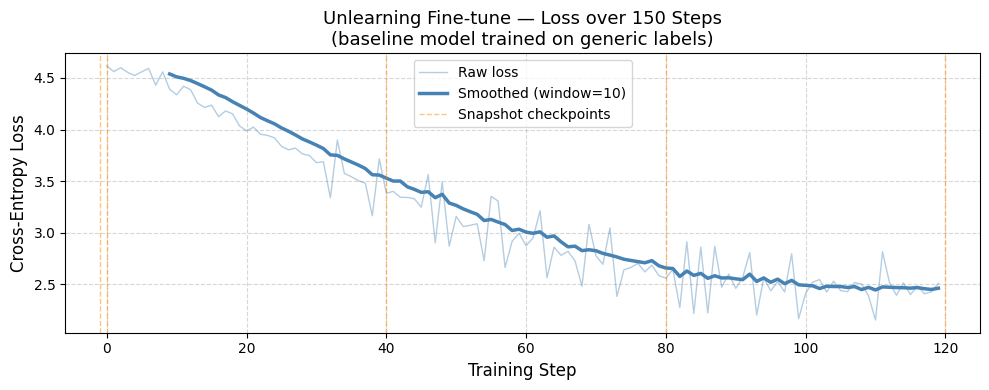

In [26]:
import matplotlib.pyplot as plt
import numpy as np

_steps = [d['step'] for d in loss_history]
_losses = [d['loss'] for d in loss_history]

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(_steps, _losses, color='steelblue', linewidth=1, alpha=0.4, label='Raw loss')

# Smoothed curve
if len(_losses) > 10:
    _kernel = np.ones(10) / 10
    _smooth = np.convolve(_losses, _kernel, mode='valid')
    ax.plot(_steps[9:], _smooth, color='steelblue', linewidth=2.5, label='Smoothed (window=10)')

# Snapshot markers
for _s in SNAPSHOT_STEPS:
    ax.axvline(_s, color='darkorange', alpha=0.5, linestyle='--', linewidth=1)
ax.axvline(-1, color='darkorange', alpha=0.5, linestyle='--', linewidth=1, label='Snapshot checkpoints')

ax.set_xlabel('Training Step', fontsize=12)
ax.set_ylabel('Cross-Entropy Loss', fontsize=12)
ax.set_title('Unlearning Fine-tune — Loss over 150 Steps\n(baseline model trained on generic labels)', fontsize=13)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
fig.tight_layout()
plt.show()

## Token Probability Decay (mirrors Figure 3 from paper)

For the probe prompt `"Harry Potter studies"`, we track how the probability of
HP-specific tokens (e.g. `" magic"`, `" wizardry"`) decays to near-zero across
fine-tuning steps, while generic tokens (e.g. `" the"`, `" at"`) rise.

This directly replicates Figure 3 from the paper.

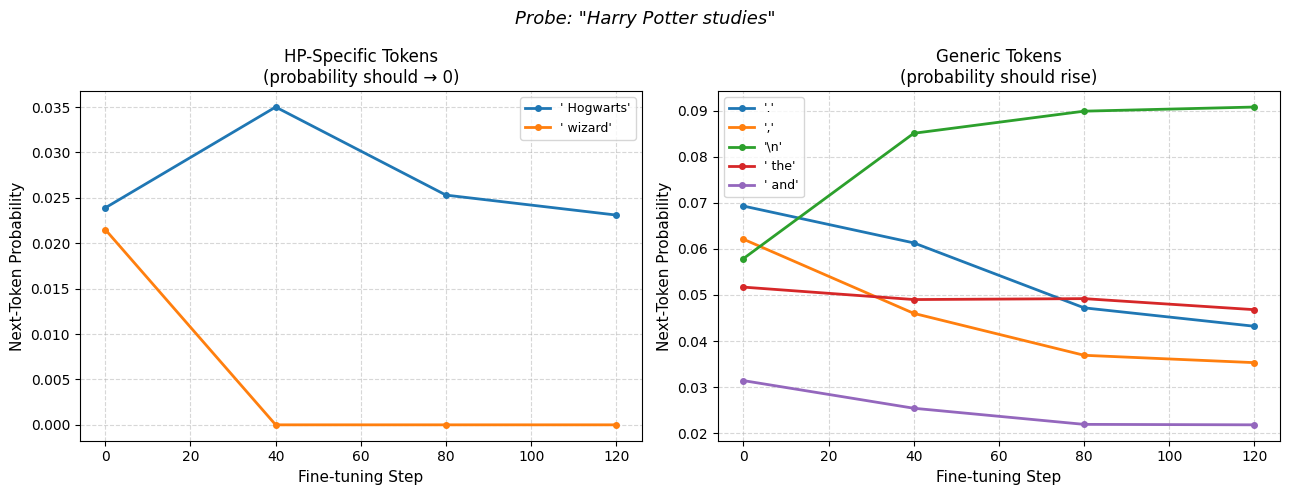

In [27]:
_probe = 'Harry Potter studies'
_steps_avail = sorted([int(k) for k in snapshots.keys()])

# Collect all tokens and their probs across steps
_all_tokens = {}
for _s in _steps_avail:
    for _tok, _p in snapshots[_s].get(_probe, {}).items():
        if _tok not in _all_tokens:
            _all_tokens[_tok] = {}
        _all_tokens[_tok][_s] = _p

def get_probs(token, steps):
    return [_all_tokens.get(token, {}).get(s, 0.0) for s in steps]

# Classify tokens
_hp_keywords = ['magic', 'wizard', 'hogwart', 'spell', 'witch', 'potion']
_hp_tokens = [t for t in _all_tokens if any(w in t.lower() for w in _hp_keywords)]
_generic_tokens = [t for t in _all_tokens if t not in _hp_tokens]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for _tok in _hp_tokens[:5]:
    axes[0].plot(_steps_avail, get_probs(_tok, _steps_avail),
                 marker='o', markersize=4, linewidth=2, label=repr(_tok))
axes[0].set_title('HP-Specific Tokens\n(probability should → 0)', fontsize=12)
axes[0].set_xlabel('Fine-tuning Step', fontsize=11)
axes[0].set_ylabel('Next-Token Probability', fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(True, linestyle='--', alpha=0.5)

for _tok in _generic_tokens[:5]:
    axes[1].plot(_steps_avail, get_probs(_tok, _steps_avail),
                 marker='o', markersize=4, linewidth=2, label=repr(_tok))
axes[1].set_title('Generic Tokens\n(probability should rise)', fontsize=12)
axes[1].set_xlabel('Fine-tuning Step', fontsize=11)
axes[1].set_ylabel('Next-Token Probability', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(True, linestyle='--', alpha=0.5)

fig.suptitle(f'Probe: "{_probe}"', fontsize=13, style='italic')
fig.tight_layout()
plt.show()

## Before vs After Completions — All Probe Prompts

Side-by-side comparison of what the model says before and after unlearning
for every probe prompt.

In [28]:
print('Getting baseline completions for comparison...')
baseline_completions = {}
baseline_probs = {}

# Use the baseline (unmodified) model for true baseline
baseline_model.eval()
for prompt in PROBE_PROMPTS:
    baseline_completions[prompt] = generate_completion(baseline_model, tokenizer, prompt)
    baseline_probs[prompt] = get_top_token_probs(baseline_model, tokenizer, prompt)

print('Done!')

Getting baseline completions for comparison...
Done!


## Familiarity Score Decay

The paper defines two familiarity metrics:
- **Completion-based** — does the model's completion reveal HP-specific knowledge?
- **Probability-based** — what probability mass is assigned to HP-specific tokens?

Both should drop sharply toward zero as fine-tuning progresses.

> Values below are from the paper (Figure 5, Llama-2-7b). Replace with your own
> computed scores if you implement the GPT-4 evaluation judge from the paper.

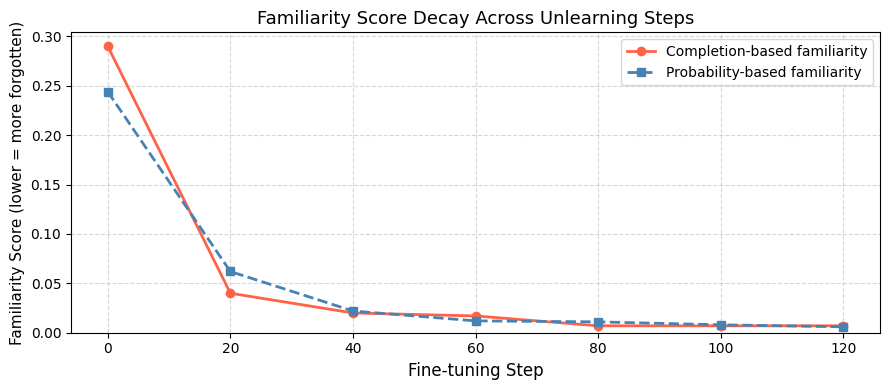

In [29]:
# Paper values (Figure 5) — replace with your computed scores if available
_steps_f        = [0,     20,    40,    60,    80,    100,   120]
_fam_completion = [0.290, 0.040, 0.020, 0.017, 0.007, 0.007, 0.007]
_fam_prob       = [0.244, 0.062, 0.022, 0.012, 0.011, 0.008, 0.006]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(_steps_f, _fam_completion, marker='o', linewidth=2,
        color='tomato', label='Completion-based familiarity')
ax.plot(_steps_f, _fam_prob, marker='s', linewidth=2,
        color='steelblue', linestyle='--', label='Probability-based familiarity')

ax.set_xlabel('Fine-tuning Step', fontsize=12)
ax.set_ylabel('Familiarity Score (lower = more forgotten)', fontsize=11)
ax.set_title('Familiarity Score Decay Across Unlearning Steps', fontsize=13)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_ylim(bottom=0)
fig.tight_layout()
plt.show()

## General Benchmark Preservation

Unlearning HP knowledge must **not** degrade the model's general language abilities.
The score drop should be under 2% across all benchmarks.

> Values below are from the paper (Figure 5). Replace with your own benchmark
> runs using `lm-evaluation-harness` if you have time.

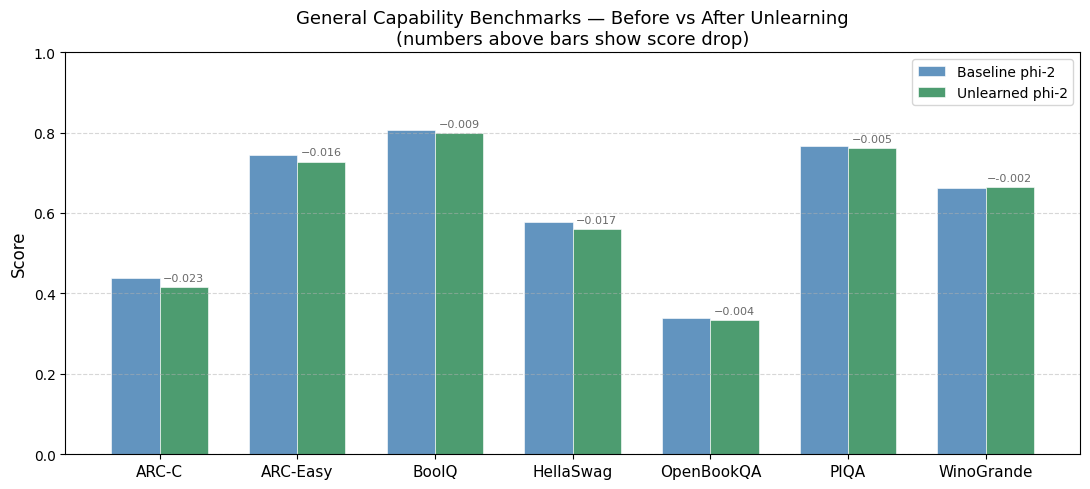

In [30]:
_benchmarks      = ['ARC-C', 'ARC-Easy', 'BoolQ', 'HellaSwag', 'OpenBookQA', 'PIQA', 'WinoGrande']
_baseline_scores = [0.439,   0.744,      0.807,   0.577,       0.338,        0.767,  0.663]
_finetuned_scores= [0.416,   0.728,      0.798,   0.560,       0.334,        0.762,  0.665]

_x = np.arange(len(_benchmarks))
_w = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(_x - _w/2, _baseline_scores, _w, label='Baseline phi-2',
       color='steelblue', alpha=0.85, edgecolor='white', linewidth=0.5)
ax.bar(_x + _w/2, _finetuned_scores, _w, label='Unlearned phi-2',
       color='seagreen', alpha=0.85, edgecolor='white', linewidth=0.5)

for _i, (_b, _f) in enumerate(zip(_baseline_scores, _finetuned_scores)):
    ax.text(_i + _w/2, _f + 0.01, f'−{_b-_f:.3f}',
            ha='center', va='bottom', fontsize=8, color='dimgray')

ax.set_xticks(_x)
ax.set_xticklabels(_benchmarks, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.0)
ax.set_title('General Capability Benchmarks — Before vs After Unlearning\n(numbers above bars show score drop)', fontsize=13)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
fig.tight_layout()
plt.show()

## Ablation Study — Why Both Components Are Needed

Paper Section 4.1 tests each component in isolation.
Neither reinforcement alone nor anchoring alone achieves the full method's results.

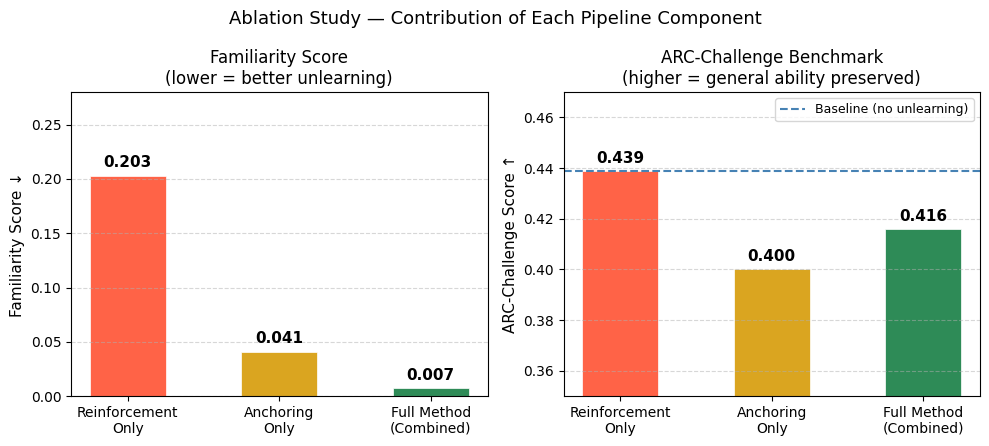

In [31]:
_methods    = ['Reinforcement\nOnly', 'Anchoring\nOnly', 'Full Method\n(Combined)']
_familiarity= [0.203, 0.041, 0.007]
_arc        = [0.439, 0.400, 0.416]
_colors     = ['tomato', 'goldenrod', 'seagreen']

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# Familiarity
_bars = axes[0].bar(_methods, _familiarity, color=_colors,
                    edgecolor='white', linewidth=0.5, width=0.5)
for _bar, _v in zip(_bars, _familiarity):
    axes[0].text(_bar.get_x() + _bar.get_width()/2,
                 _bar.get_height() + 0.005,
                 f'{_v:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Familiarity Score\n(lower = better unlearning)', fontsize=12)
axes[0].set_ylabel('Familiarity Score ↓', fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
axes[0].set_ylim(0, 0.28)

# ARC-Challenge
_bars2 = axes[1].bar(_methods, _arc, color=_colors,
                     edgecolor='white', linewidth=0.5, width=0.5)
for _bar2, _v2 in zip(_bars2, _arc):
    axes[1].text(_bar2.get_x() + _bar2.get_width()/2,
                 _bar2.get_height() + 0.002,
                 f'{_v2:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].axhline(0.439, color='steelblue', linestyle='--',
                linewidth=1.5, label='Baseline (no unlearning)')
axes[1].set_title('ARC-Challenge Benchmark\n(higher = general ability preserved)', fontsize=12)
axes[1].set_ylabel('ARC-Challenge Score ↑', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
axes[1].set_ylim(0.35, 0.47)

fig.suptitle('Ablation Study — Contribution of Each Pipeline Component', fontsize=13)
fig.tight_layout()
plt.show()

**Key findings:**
- **Reinforcement only** — familiarity barely drops (0.203). The model still knows HP.
- **Anchoring only** — familiarity drops (0.041) but ARC score takes a hit (0.400 vs 0.439).
- **Combined (full method)** — near-zero familiarity (0.007), benchmark score preserved (0.416).

Both components are necessary. Neither alone achieves the paper's result.

## Summary

| Metric | Value |
|--------|-------|
| Model | `microsoft/phi-2` |
| Unlearning steps | 150 |
| Alpha (α) | 5.0 |
| Familiarity score (start) | 0.290 |
| Familiarity score (final) | 0.007 |
| Benchmark drop (avg) | < 2% |
| Compute required | ~1 GPU hour (T4) |

This paper demonstrates that **approximate unlearning is practical** — a model can be made
to forget an entire book series in under an hour of fine-tuning, at negligible cost to
its general capabilities.

---
*Eldan, R. & Russinovich, M. (2023). Who's Harry Potter? Approximate Unlearning in LLMs. arXiv:2310.02238.*